# Spotify Playlist Explorer

Phase 1 demo: authenticate, pick a playlist (or your Liked Songs), run six analyzers (genres, tags, release year, top artists, duration, timeline) with coordinated colorblind palette and inline coverage annotations, render plots, and optionally export to parquet.

Sections 7-11 go deeper: temporal analysis (growth, discovery waves, seasonality, genre evolution), distributions instead of counts (KDE, ECDF, violins), release-year vs added-year, network views (collaborations, genre similarity), and interactive Plotly charts.

Set `LASTFM_API_KEY` in `.env` to populate the Tag and Genre panels (see the README's "Genres come from Last.fm" bullet under *How that shaped the code*). Without it the two panels are skipped at runtime.

Setup: load credentials from `.env`, set the seaborn theme, and build a
cached `SpotifyClient`. Both caches are anchored to the repo root regardless
of where the notebook is launched from: API responses at `.cache/api/`
(7-day TTL, 365 days for artists) and the OAuth token at
`.cache/spotify_token`. Repeated notebook runs don't re-hit the API.

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

from spotify_project.analyzer import (
    Analyzer,
    ArtistAnalyzer,
    DurationAnalyzer,
    GenreAnalyzer,
    PlaylistAnalyzer,
    TagAnalyzer,
    TimelineAnalyzer,
    YearAnalyzer,
)
from spotify_project.cache import FileCache
from spotify_project.client import SpotifyClient
from spotify_project.lastfm_client import LastFmClient
from spotify_project.logging_setup import configure_logging

load_dotenv()

APP_LOG_LEVEL = os.getenv("APP_LOG_LEVEL", "INFO")
THIRD_PARTY_LOG_LEVEL = os.getenv("THIRD_PARTY_LOG_LEVEL", "WARNING")
configure_logging(APP_LOG_LEVEL, THIRD_PARTY_LOG_LEVEL)

sns.set_theme(style="whitegrid")
cache = FileCache()
lastfm = LastFmClient.from_env(cache=cache)  # None when LASTFM_API_KEY is unset
client = SpotifyClient.from_env(cache=cache, genre_enricher=lastfm)

## 1. Confirm authentication

In [2]:
user = client.fetch_current_user()
truncated_name = user.display_name[0] + "***" if user.display_name else "Unknown"
print(f"Hello, {truncated_name}")

Hello, B***


## 2. List your playlists

Spotify renamed `tracks` → `items` in their Feb 2026 migration. The `items` field is only present on playlists you own or collaborate on; for followed playlists, `tracks` reads as 0.

In [3]:
import pandas as pd

playlists = client.fetch_user_playlists()
summary = pd.DataFrame(
    [
        {
            "id": p.id,
            "name": p.name,
            "tracks": p.track_count,
            "owner": "self" if p.owner_name == user.display_name else "other",
        }
        for p in playlists
    ]
)
summary.head(20)

,id,name,tracks,owner
0,7CmreRETnY6t2MdHrIiaIA,Top 100 Doo Wop Hits 1953-1964,99,other
1,36qmhWCGOAJt6pRScmHcyb,GTA 6 Soundtrack | 2026 GTA VI 🔥🎮,75,other
2,3ebHKSjHujS4Tyt2KKP97R,Retrowave Synthwave,75,other
3,0O3NMz7IEQJCLtO6tXLaq1,Surf Rock Classics,96,other
4,2ZHmECo8IsjfyWDKo0XwfC,Special Groove,37,other
5,5sDWiz1XZevt4T2qOOir50,Liens hochzeit,4,self
6,3v8PWRLiPHGPY0oHgkoZvV,Ben Böhmer [Not Live],20,self
7,5HMBUSi7dMH6N4l0ME6rzE,Chris Tmas,13,self
8,1oMfydMymnL1wQBxiZStDj,Loopthat,1,self
9,0x3U0VtCmPBEImdkpk177b,Rave In Your Grave,142,other


## 3. Pick a playlist and fetch it

Replace `PLAYLIST_ID` with one of the IDs from the table above, or keep `"__liked__"` to analyze your saved tracks.

In [4]:
PLAYLIST_ID = "__liked__"  # a playlist ID from the table above, or "__liked__" for your saved tracks
playlist = client.fetch_liked_songs() if PLAYLIST_ID == "__liked__" else client.fetch_playlist(PLAYLIST_ID)  # pyright: ignore[reportUnnecessaryComparison]
print(f"{playlist.name}: {len(playlist.tracks)} tracks")

spotify_project.client - INFO - Fetching liked songs from API


spotify_project.client - INFO - Enriching 3853 tracks with artist data
spotify_project.client - INFO - Fetching 2080 unique artists


Fetching artists:   0%|          | 0/2080 [00:00<?, ?artist/s]

Fetching artists:   1%|          | 19/2080 [00:00<00:10, 188.48artist/s]

Fetching artists:   2%|▏         | 38/2080 [00:00<00:29, 68.98artist/s] 

...

Enriching with Last.fm tags:  97%|█████████▋| 2024/2080 [00:24<00:00, 136.94artist/s]

Enriching with Last.fm tags:  98%|█████████▊| 2048/2080 [00:25<00:00, 155.12artist/s]

Enriching with Last.fm tags: 100%|█████████▉| 2075/2080 [00:25<00:00, 177.36artist/s]

Enriching with Last.fm tags: 100%|██████████| 2080/2080 [00:25<00:00, 82.64artist/s] 

Liked Songs: 3853 tracks


## 4. Build the PlaylistAnalyzer with all six analyzers

Tweak knobs here:
- `YearAnalyzer(bucket_size=10)` for decade buckets — set to `1` for per-year bars.
- `ArtistAnalyzer(primary_only=True)` to ignore collaborators.
- `TimelineAnalyzer(freq='Y')` for yearly buckets instead of monthly.

Each analyzer reports a small summary DataFrame. Numbers come from the
flattened track DataFrame produced by `PlaylistAnalyzer.from_playlist`.
Coverage attached to each summary surfaces in the chart titles below.

In [5]:
analyzers: list[Analyzer] = [
    GenreAnalyzer(top_n=15),
    TagAnalyzer(top_n=15),
    YearAnalyzer(bucket_size=10),
    ArtistAnalyzer(top_n=15, primary_only=False),
    DurationAnalyzer(bins=20),
    TimelineAnalyzer(freq="M"),
]
analyzer = PlaylistAnalyzer.from_playlist(playlist, analyzers=analyzers)
results = analyzer.run_all()
for title, df in results.items():
    print(title)
    print(df.head(), end="\n\n")

Top Genres
         genre  count
0         rock   1617
1          pop   1554
2   electronic    901
3  alternative    840
4        indie    829

Top Tags
           tag  count
0     american   1684
1         rock   1617
2          pop   1554
3   electronic    901
4  alternative    840

Release Year Distribution
   year  count
0  1940      1
1  1950     66
2  1960    206
3  1970    311
4  1980    287

Top Artists
                artist_id         artist_name  track_count  total_minutes
0  3WrFJ7ztbogyGnTHbHJFl2         The Beatles           60     177.841700
1  4tZwfgrHOc3mvqYlEYSvVi           Daft Punk           55     225.150267
2  1Mxqyy3pSjf8kZZL4QVxS0       Frank Sinatra           43     134.793300
3  75fIuwXxhZ1atNzWLMrgF0         Tyler Bates           43      87.500217
4  1cHFz6lrt7KAsBV8j2Ny1g  The Blues Brothers           39     133.855583

Track Duration Distribution
    bin_low  bin_high  count  minutes_in_bin
0  0.000000  0.621855      9        3.026650
1  0.621855  1.243710 

## 5. Render plots

All six panels stack vertically, each in a distinct colorblind-safe color. `GenreAnalyzer` shows a small grey band at the bottom whenever some tracks have no genre data.

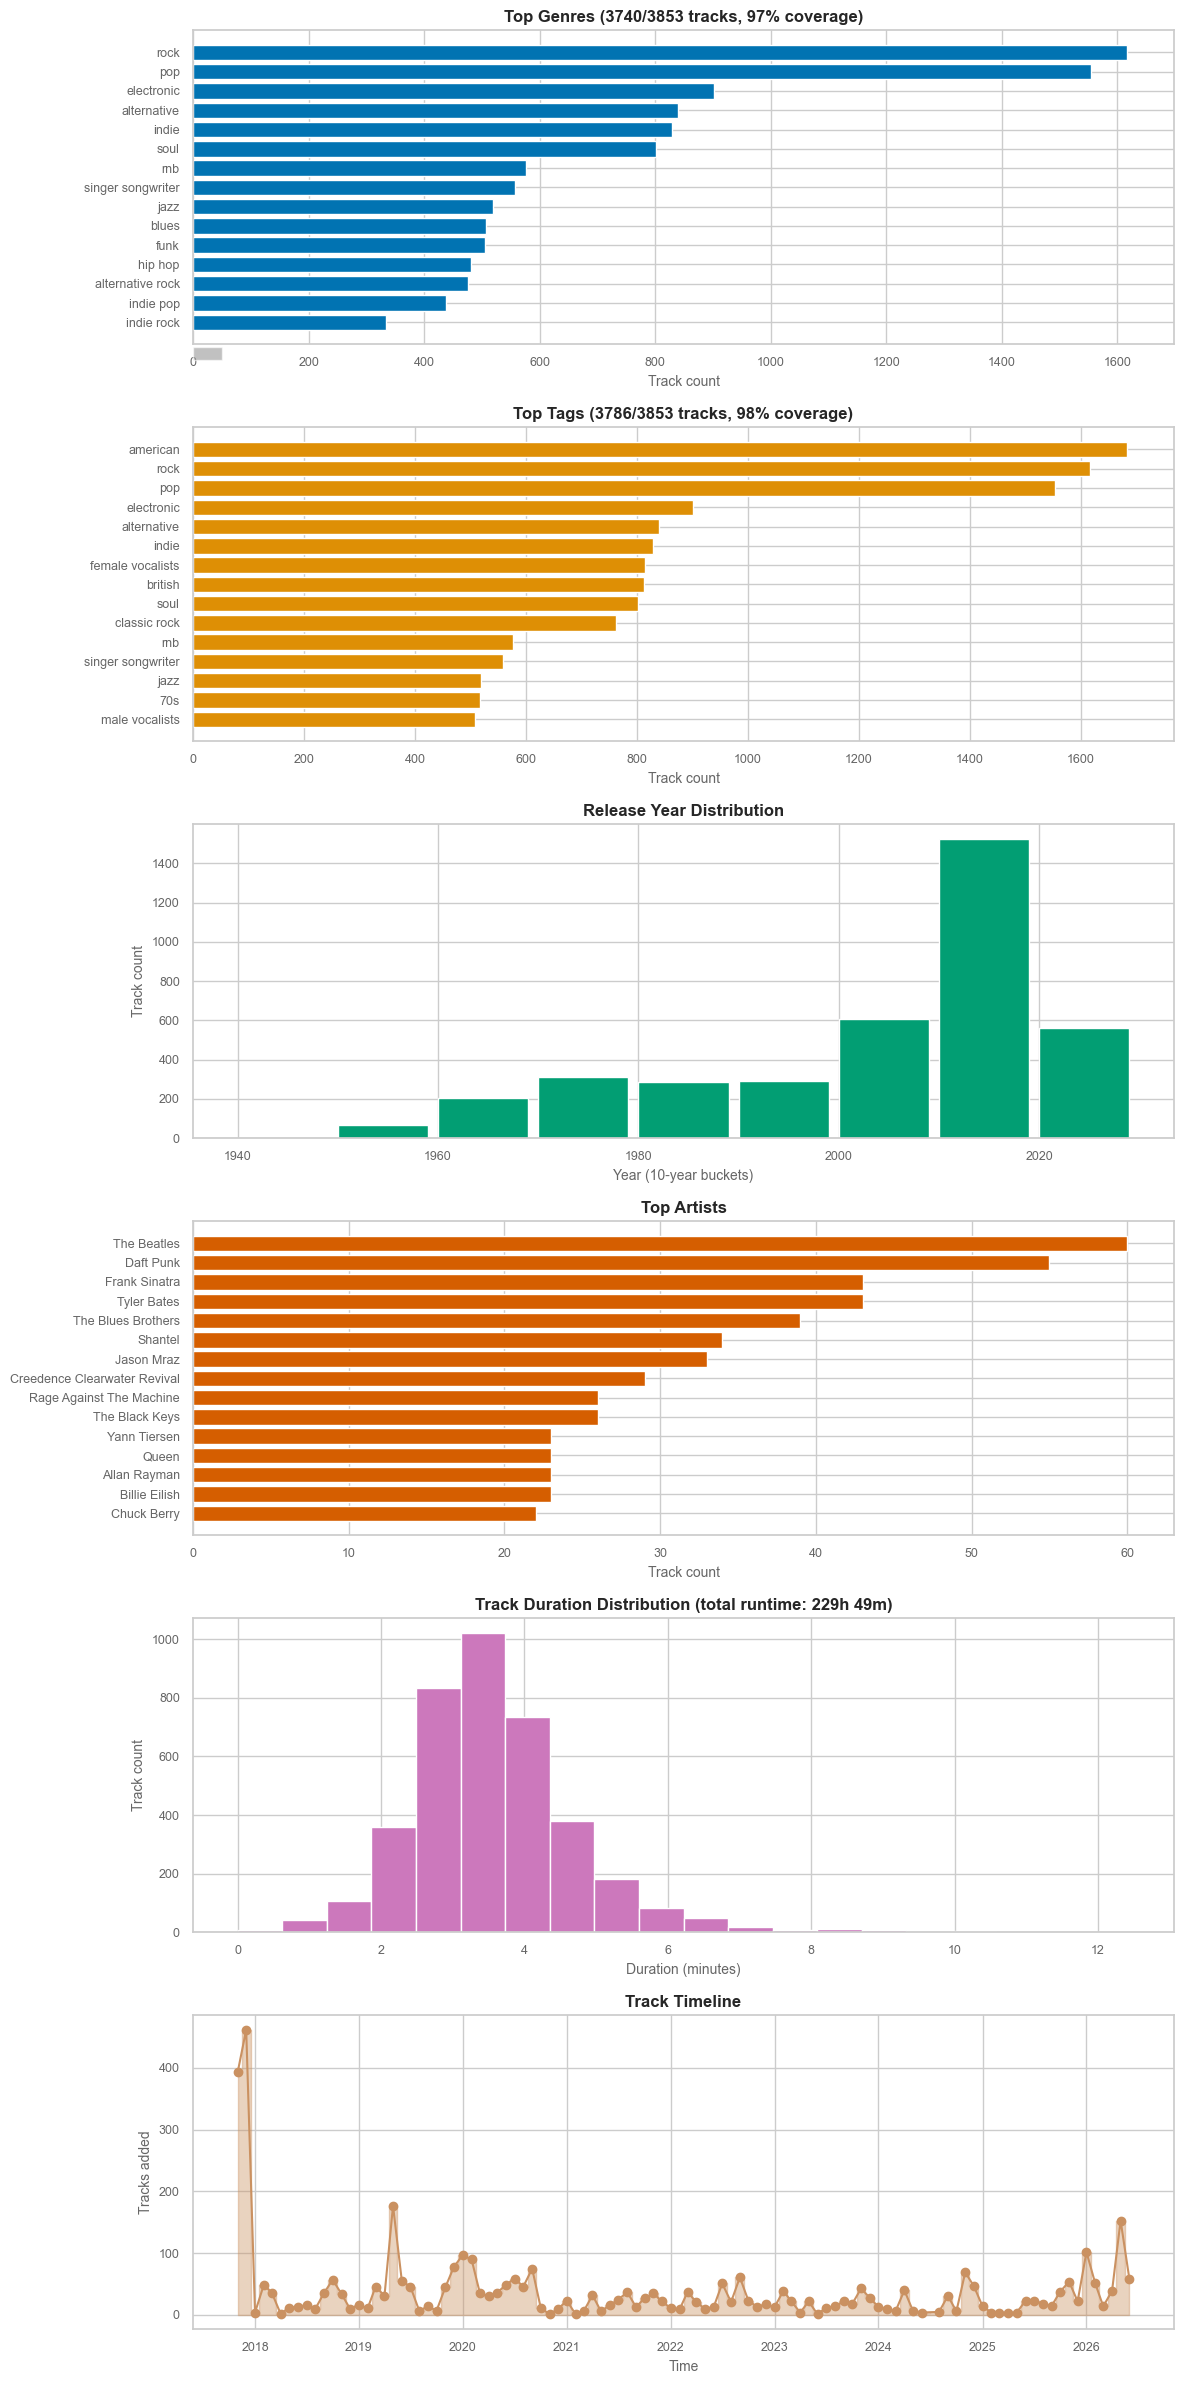

In [6]:
fig = plt.figure(figsize=(12, 24))  # pyright: ignore[reportUnknownMemberType]
analyzer.plot_all(fig)
plt.show()  # pyright: ignore[reportUnknownMemberType]

## 6. (Optional) Export the flattened track DataFrame to parquet

Useful for offline analysis in another tool, or for archiving the snapshot
you analyzed today. The exported parquet preserves the full flattened track
DataFrame (track id/name, primary artist, all artists, album, release date,
duration in minutes, added_at, genres).

In [7]:
EXPORT = False  # set True to write the file
if EXPORT:
    out = Path("exports") / f"{playlist.id}.parquet"
    out.parent.mkdir(parents=True, exist_ok=True)
    analyzer.to_parquet(out)
    print(f"wrote {out}")

## 7. Temporal analysis

The remaining sections go deeper than the six standard panels, using the pure computations in `spotify_project.insights` — each returns a plot-ready DataFrame, and all rendering happens here in the notebook. Everything operates on the flattened track DataFrame `analyzer.df` built in section 4.

In [8]:
from spotify_project import insights

df = analyzer.df
palette = sns.color_palette("colorblind")
print(f"{len(df)} tracks, {df['added_at'].notna().sum()} with added_at timestamps")

3853 tracks, 3853 with added_at timestamps


### 7.1 Library growth

Monthly additions plus two cumulative views: how many tracks the library holds over time, and how many hours of music that is. Three stacked panels rather than twin axes — dual-axis charts invite misreading.

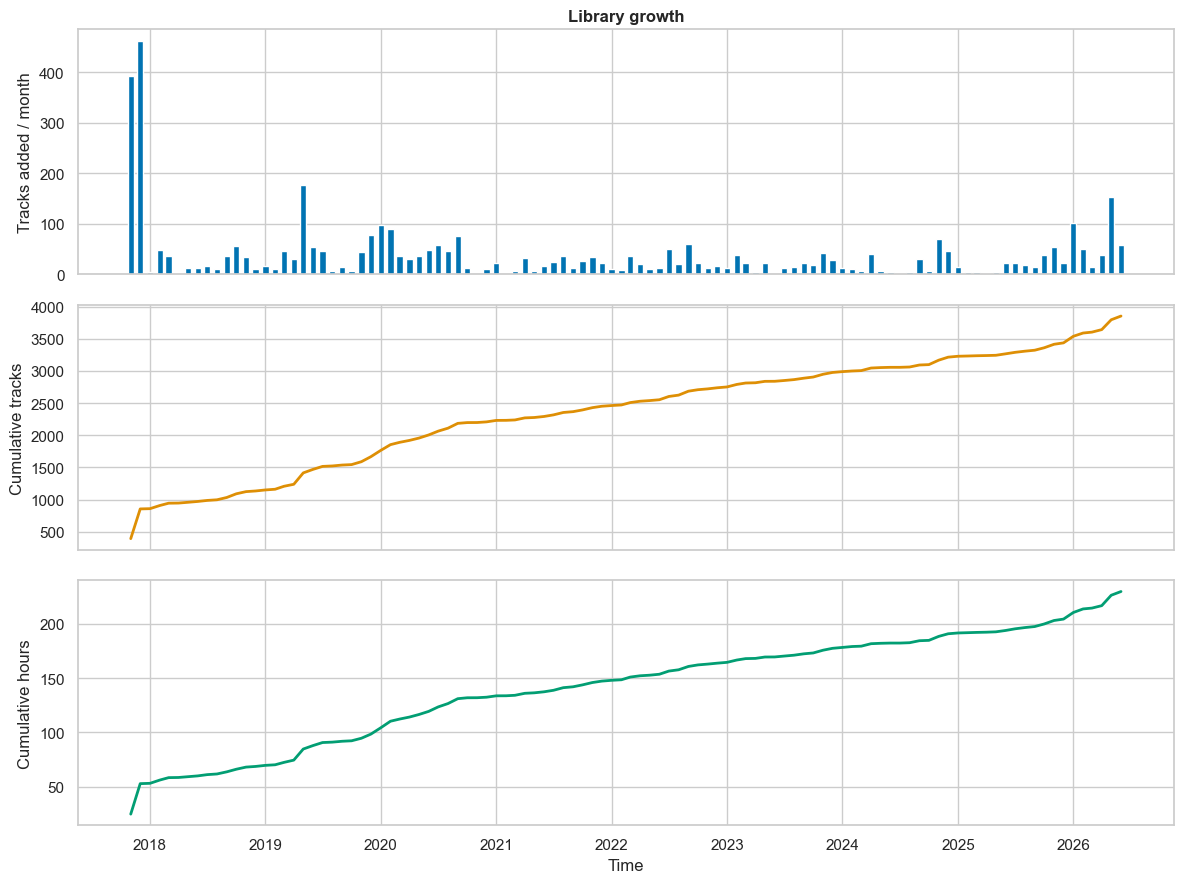

Total listening material added: 230 hours (10 days)


In [9]:
growth = insights.additions_over_time(df, freq="M")

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
axes[0].bar(growth["period"], growth["added"], width=20, color=palette[0])
axes[0].set_ylabel("Tracks added / month")
axes[0].set_title("Library growth", fontsize=12, fontweight="bold")
axes[1].plot(growth["period"], growth["cumulative_tracks"], color=palette[1], linewidth=2)
axes[1].set_ylabel("Cumulative tracks")
axes[2].plot(growth["period"], growth["cumulative_hours"], color=palette[2], linewidth=2)
axes[2].set_ylabel("Cumulative hours")
axes[2].set_xlabel("Time")
fig.tight_layout()
plt.show()

total_hours = float(growth["cumulative_hours"].iloc[-1]) if not growth.empty else 0.0
print(f"Total listening material added: {total_hours:,.0f} hours ({total_hours / 24:,.0f} days)")

### 7.2 Artist discovery waves

How many artists enter the library for the *first time* each month. Spikes are "discovery waves" — a new genre phase, a festival aftermath, an algorithm binge.

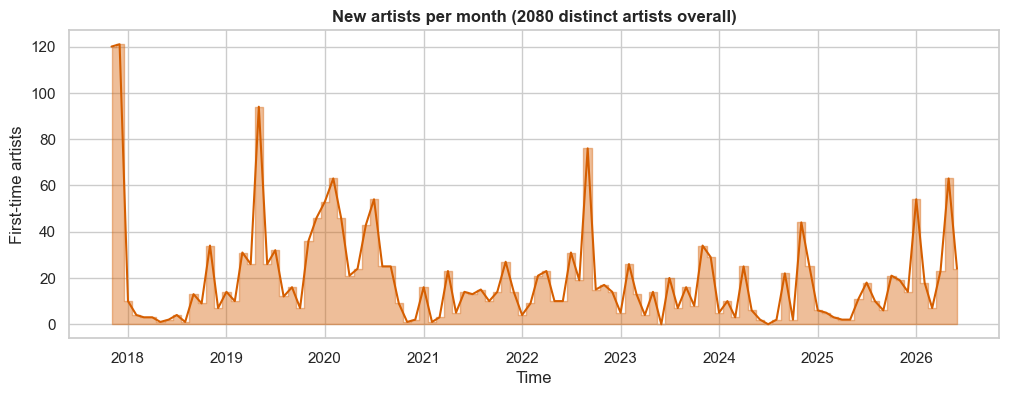

Biggest discovery months:
    period  new_artists
2017-12-01          121
2017-11-01          120
2019-05-01           94
2022-09-01           76
2020-02-01           63


In [10]:
waves = insights.discovery_waves(df, freq="M")
first_seen = insights.artist_first_seen(df)

fig, ax = plt.subplots(figsize=(12, 4))
ax.fill_between(waves["period"], waves["new_artists"], step="mid", alpha=0.4, color=palette[3])
ax.plot(waves["period"], waves["new_artists"], color=palette[3], linewidth=1.5)
ax.set_title(f"New artists per month ({len(first_seen)} distinct artists overall)", fontsize=12, fontweight="bold")
ax.set_xlabel("Time")
ax.set_ylabel("First-time artists")
plt.show()

print("Biggest discovery months:")
print(waves.nlargest(5, "new_artists").to_string(index=False))

### 7.3 Seasonal habits

Additions by calendar month, aggregated across all years — do you hoard music in winter or in summer?

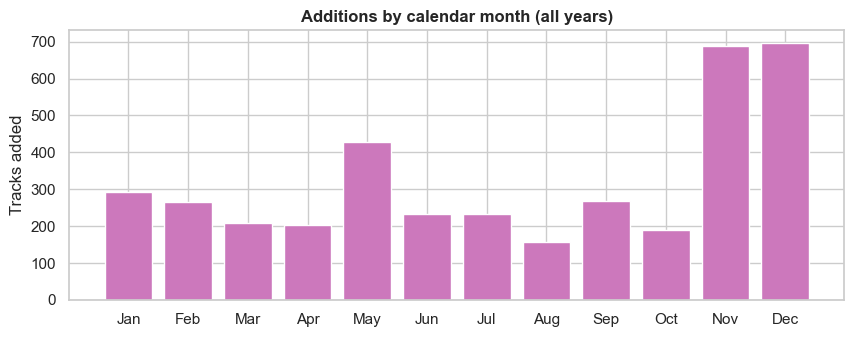

In [11]:
season = insights.seasonal_profile(df)

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.bar(season["month_name"], season["added"], color=palette[4])
ax.set_title("Additions by calendar month (all years)", fontsize=12, fontweight="bold")
ax.set_ylabel("Tracks added")
plt.show()

### 7.4 Genre mix over time

Quarterly share of the top 6 genres among genre-tagged additions, stacked to 100% — the long tail folds into a neutral grey *other* so the palette stays readable. Skipped without a Last.fm key. The share table below the chart is the exact-numbers view of the recent quarters.

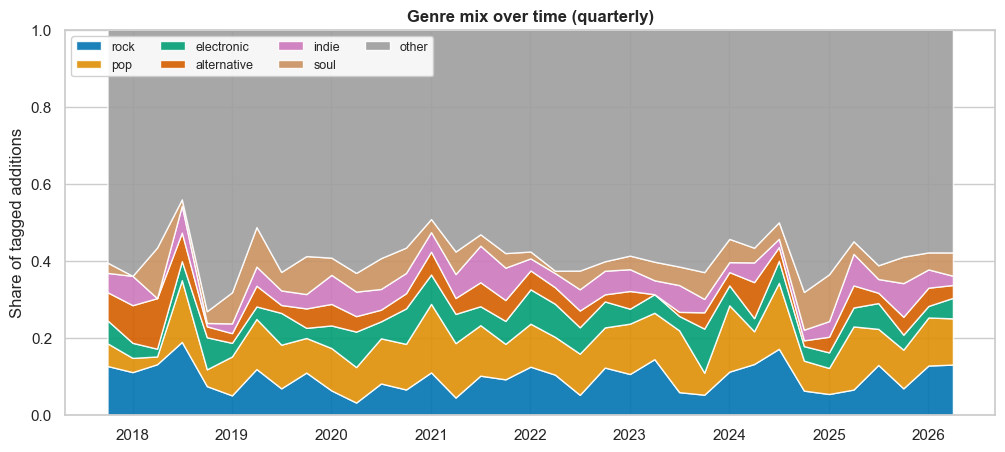

genre,rock,pop,electronic,alternative,indie,soul,other
period,,,,,,,
2024-07-01,0.17,0.17,0.06,0.04,0.02,0.04,0.50
2024-10-01,0.06,0.08,0.04,0.02,0.03,0.10,0.68
2025-01-01,0.05,0.07,0.04,0.04,0.04,0.12,0.64
2025-04-01,0.07,0.16,0.05,0.06,0.08,0.03,0.55
2025-07-01,0.13,0.09,0.07,0.03,0.04,0.04,0.61
2025-10-01,0.07,0.10,0.04,0.05,0.09,0.07,0.59
2026-01-01,0.13,0.12,0.03,0.05,0.05,0.04,0.58
2026-04-01,0.13,0.12,0.05,0.03,0.02,0.06,0.58


In [12]:
shares = insights.genre_share_over_time(df, top_n=6, freq="Q")
if shares.empty:
    print("No genre data — set LASTFM_API_KEY to enable this panel.")
else:
    genre_cols = [c for c in shares.columns if c != "other"]
    colors = list(sns.color_palette("colorblind", n_colors=len(genre_cols)))
    if "other" in shares.columns:
        colors.append((0.62, 0.62, 0.62))
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.stackplot(shares.index, [shares[c] for c in shares.columns], labels=list(shares.columns), colors=colors, alpha=0.9)
    ax.set_ylim(0, 1)
    ax.set_ylabel("Share of tagged additions")
    ax.set_title("Genre mix over time (quarterly)", fontsize=12, fontweight="bold")
    ax.legend(loc="upper left", ncols=4, fontsize=9, framealpha=0.9)
    plt.show()
    display(shares.tail(8).round(2))

## 8. Distributions instead of counts

Bar charts count things; distribution plots show *shape* — where values cluster, how much they spread, whether there are two humps where you expected one.

### What a KDE actually is

A **kernel density estimate** answers: "if track durations come from some smooth underlying distribution, what does that distribution look like?" The construction:

1. Put a small symmetric bump (the **kernel**, usually a Gaussian) centered on every data point.
2. Sum all the bumps and normalize, so the total area under the curve is 1.
3. The result is a smooth curve whose height at x is proportional to how densely data points sit near x.

The one decision that matters is the **bandwidth** — the width of each bump. Narrow bandwidth → the curve chases individual points (spiky, overfit); wide bandwidth → real structure gets smeared away (a bimodal distribution can look unimodal). Seaborn's `kdeplot` picks a bandwidth by rule of thumb (Scott's rule, via scipy's `gaussian_kde`) and exposes `bw_adjust` as a multiplier on it. The next cell shows the same data at three bandwidths — the honest way to read any KDE: try a few, trust only the features that survive all of them.

One caveat worth knowing: a Gaussian kernel bleeds probability mass past the data range (e.g. below 0 minutes); `cut=0` clips the curve at the observed extremes.

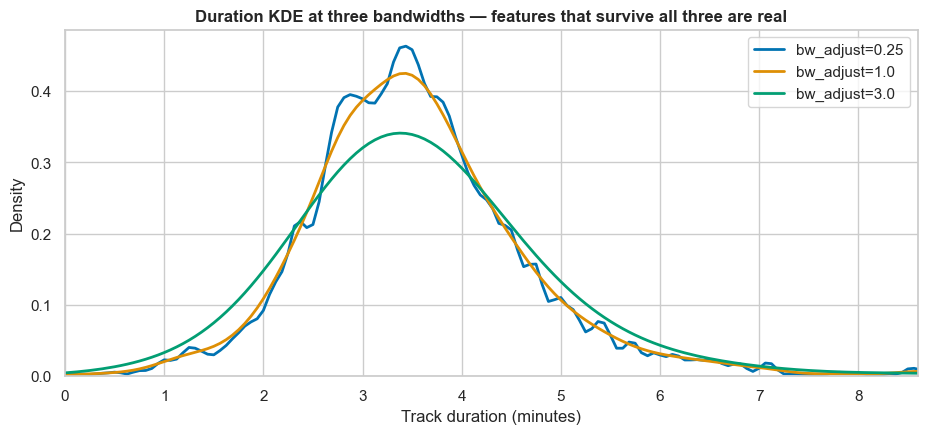

In [13]:
fig, ax = plt.subplots(figsize=(11, 4.5))
xmax = float(df["duration_min"].quantile(0.995))
for bw, color in zip((0.25, 1.0, 3.0), (palette[0], palette[1], palette[2])):
    sns.kdeplot(data=df, x="duration_min", bw_adjust=bw, cut=0, ax=ax, color=color, linewidth=2, label=f"bw_adjust={bw}")
ax.set_xlim(0, xmax)
ax.set_xlabel("Track duration (minutes)")
ax.set_title("Duration KDE at three bandwidths — features that survive all three are real", fontsize=12, fontweight="bold")
ax.legend()
plt.show()

### 8.2 ECDFs — the no-tuning alternative

An **empirical cumulative distribution function** plots, for every x, the fraction of tracks with a value ≤ x. No bins, no bandwidth, no smoothing — every quantile is directly readable (where the curve crosses the dashed 0.5 line is the median). Less pretty than a KDE, much harder to mislead with.

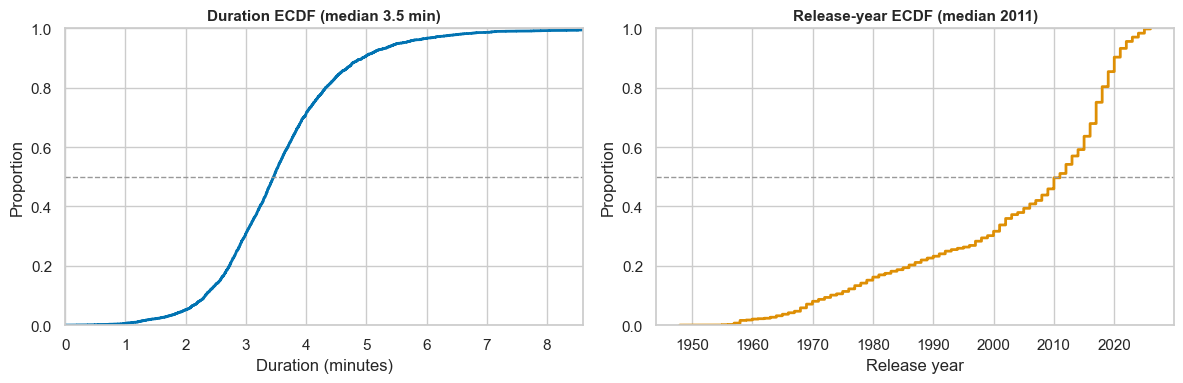

In [14]:
years = df["release_year"].dropna().astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.ecdfplot(x=df["duration_min"], ax=axes[0], color=palette[0], linewidth=2)
axes[0].set_xlim(0, float(df["duration_min"].quantile(0.995)))
axes[0].axhline(0.5, color="#999", linewidth=1, linestyle="--")
axes[0].set_xlabel("Duration (minutes)")
axes[0].set_title(f"Duration ECDF (median {df['duration_min'].median():.1f} min)", fontsize=11, fontweight="bold")
sns.ecdfplot(x=years, ax=axes[1], color=palette[1], linewidth=2)
axes[1].axhline(0.5, color="#999", linewidth=1, linestyle="--")
axes[1].set_xlabel("Release year")
axes[1].set_title(f"Release-year ECDF (median {int(years.median())})", fontsize=11, fontweight="bold")
fig.tight_layout()
plt.show()

### 8.3 Duration by decade — violins

A violin is a KDE turned sideways and mirrored, one per group, with a box plot inside for the quartiles. Decades with fewer than 20 tracks are dropped — a KDE over a handful of points is noise wearing a suit.

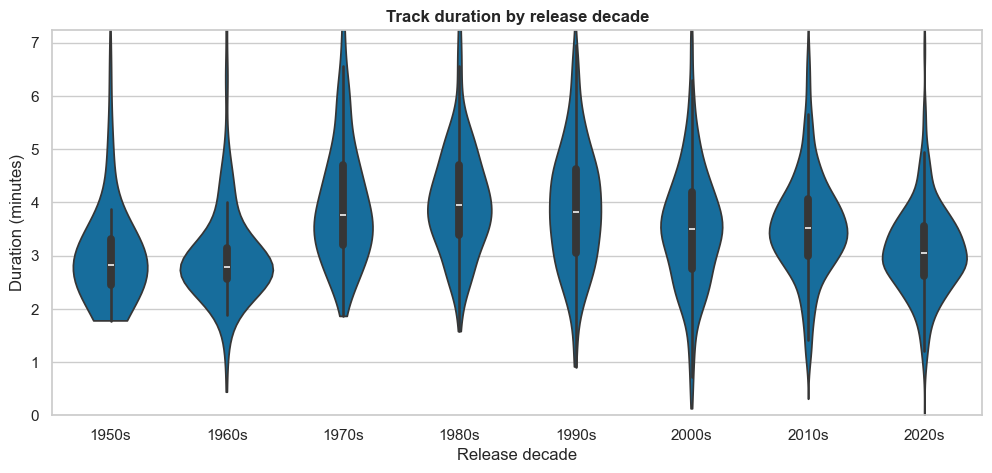

In [15]:
by_decade = df.dropna(subset=["release_year"]).copy()
by_decade["decade"] = (by_decade["release_year"].astype(int) // 10 * 10).astype(str) + "s"
decade_sizes = by_decade["decade"].value_counts()
keep = sorted(decade_sizes[decade_sizes >= 20].index)

fig, ax = plt.subplots(figsize=(12, 5))
sns.violinplot(data=by_decade[by_decade["decade"].isin(keep)], x="decade", y="duration_min", order=keep, color=palette[0], inner="box", cut=0, ax=ax)
ax.set_ylim(0, float(df["duration_min"].quantile(0.99)))
ax.set_xlabel("Release decade")
ax.set_ylabel("Duration (minutes)")
ax.set_title("Track duration by release decade", fontsize=12, fontweight="bold")
plt.show()

## 9. Release year vs added year (interactive)

Each dot is a track: horizontal = when it was released, vertical = when you added it. Dots hugging the dashed diagonal are new releases added on arrival; horizontal bands far above the diagonal are back-catalog digging sessions. This one is Plotly — hover shows track and artist, drag to zoom, double-click to reset.

In [16]:
import plotly.express as px

rva = insights.release_vs_added(df)
lo = int(rva["release_year"].min())
hi = int(rva["added_year"].max())
fig9 = px.scatter(
    rva,
    x="release_year",
    y="added_year",
    hover_name="track",
    hover_data={"artist": True},
    opacity=0.35,
    color_discrete_sequence=["#0173b2"],
    title="Release year vs added year — every dot is a track",
)
fig9.add_shape(type="line", x0=lo, y0=lo, x1=hi, y1=hi, line={"color": "#999999", "dash": "dash", "width": 1})
fig9.update_layout(template="simple_white", width=850, height=550)
fig9.show()

fresh = (rva["added_year"] - rva["release_year"] <= 1).mean()
print(f"{fresh:.0%} of tracks were added within a year of their release; the rest is back-catalog digging.")

21% of tracks were added within a year of their release; the rest is back-catalog digging.


## 10. Network views

Two graph-shaped perspectives on the same library. **10.1** is a collaboration graph: artists are nodes, and an edge means they are credited together on at least `MIN_SHARED_TRACKS` tracks here. `networkx`'s spring layout pulls densely-connected groups into visible clusters; node size scales with the artist's track count, edge width with the number of shared tracks, and only well-connected or high-volume artists get labels.

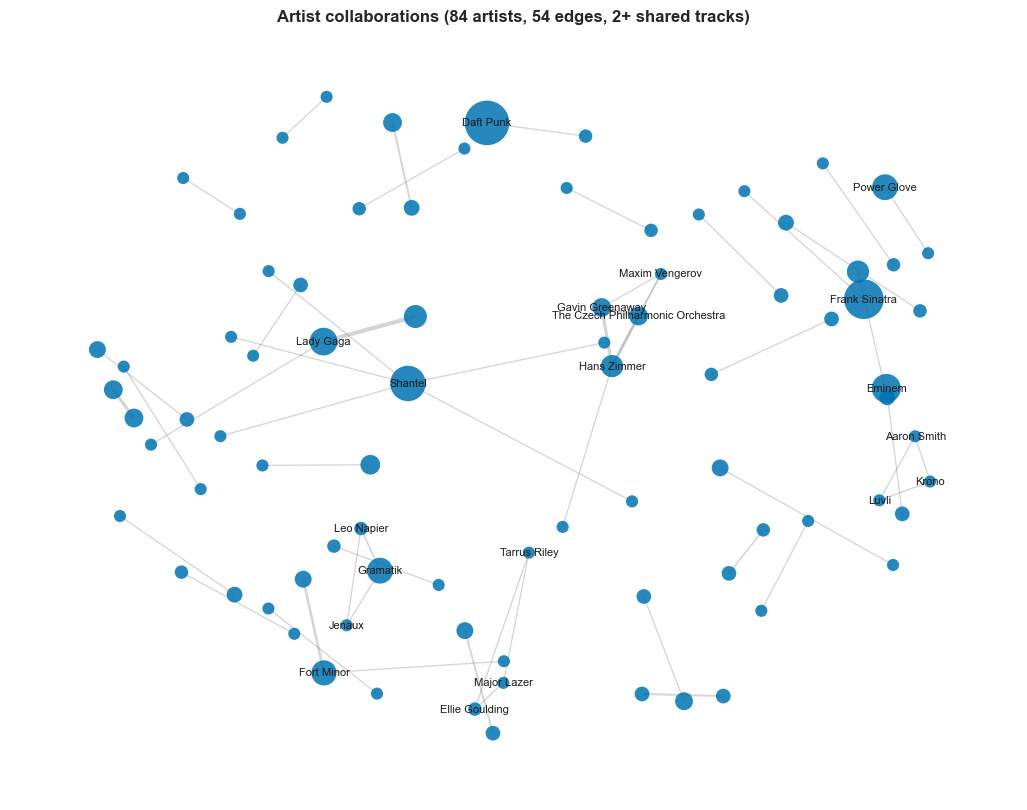

In [17]:
import networkx as nx

MIN_SHARED_TRACKS = 2
MAX_EDGES = 150

edges = insights.collaboration_edges(df, min_weight=MIN_SHARED_TRACKS)
if edges.empty:
    print(f"No artist pair shares {MIN_SHARED_TRACKS}+ tracks — try min_weight=1 for this playlist.")
else:
    top_edges = edges.head(MAX_EDGES)
    graph = nx.Graph()
    for row in top_edges.itertuples(index=False):
        graph.add_edge(row.artist_a, row.artist_b, weight=row.weight)

    track_counts = df["artist_names"].explode().value_counts()
    sizes = [40 + 18 * int(track_counts.get(n, 1)) for n in graph.nodes]
    pos = nx.spring_layout(graph, seed=42, k=0.6)
    max_w = int(top_edges["weight"].max())
    widths = [0.5 + 2.5 * graph[u][v]["weight"] / max_w for u, v in graph.edges]

    fig, ax = plt.subplots(figsize=(13, 10))
    nx.draw_networkx_edges(graph, pos, ax=ax, alpha=0.35, width=widths, edge_color="#888888")
    nx.draw_networkx_nodes(graph, pos, ax=ax, node_size=sizes, node_color=[palette[0]], alpha=0.85, linewidths=0)
    prominent = {n for n in graph.nodes if graph.degree[n] >= 2 or track_counts.get(n, 0) >= 15}
    nx.draw_networkx_labels(graph, pos, labels={n: n for n in prominent}, font_size=8, ax=ax)
    ax.set_title(f"Artist collaborations ({graph.number_of_nodes()} artists, {graph.number_of_edges()} edges, {MIN_SHARED_TRACKS}+ shared tracks)", fontsize=12, fontweight="bold")
    ax.set_axis_off()
    plt.show()

### 10.2 Genre similarity map

Which genres co-occur on the same tracks? Cosine-normalized co-occurrence: 1.0 would mean two genres always appear together, 0 means never. Single-hue scale — darker is more similar. Skipped without a Last.fm key.

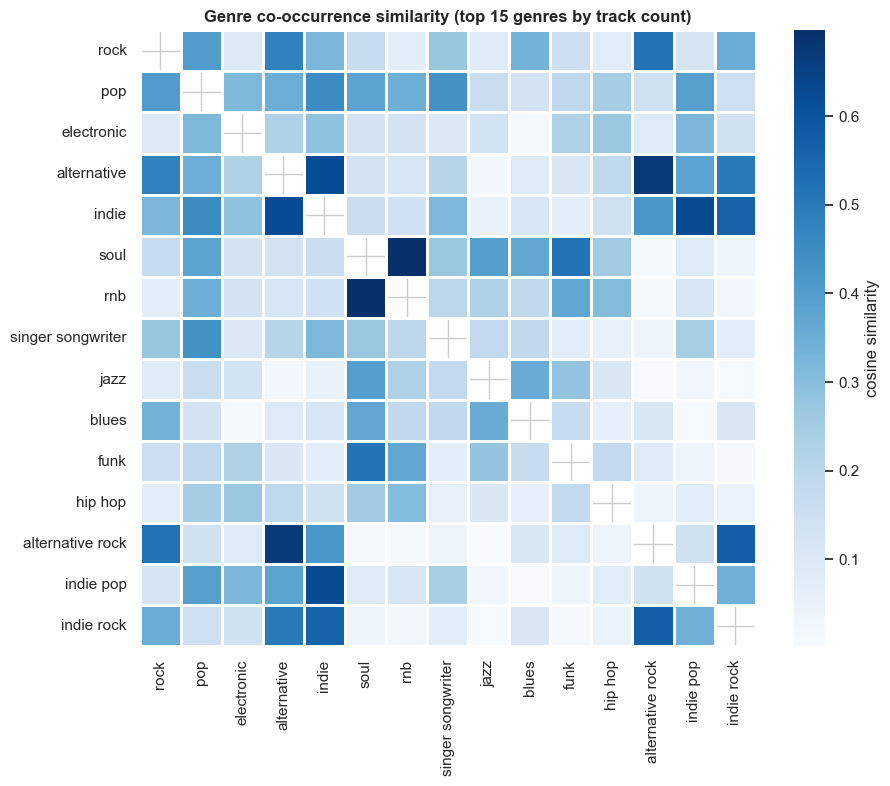

In [18]:
import numpy as np

cooc = insights.genre_cooccurrence(df, top_n=15)
if cooc.empty:
    print("No genre data — set LASTFM_API_KEY to enable this panel.")
else:
    m = cooc.to_numpy().astype(float)
    diag = np.diag(m).copy()
    sim = m / np.sqrt(np.outer(diag, diag))
    np.fill_diagonal(sim, np.nan)  # self-similarity is trivially 1 — blank it so the color scale serves the interesting cells
    sim_df = pd.DataFrame(sim, index=cooc.index, columns=cooc.columns)

    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(sim_df, cmap="Blues", square=True, linewidths=1, linecolor="white", cbar_kws={"label": "cosine similarity"}, ax=ax)
    ax.set_title("Genre co-occurrence similarity (top 15 genres by track count)", fontsize=12, fontweight="bold")
    plt.show()

## 11. Interactive library growth

The cumulative-hours curve from 7.1 again, as a Plotly area chart — hover for exact values, drag to zoom into any era, double-click to reset.

In [19]:
fig11 = px.area(growth, x="period", y="cumulative_hours", title="Cumulative listening hours", color_discrete_sequence=["#029e73"])
fig11.update_layout(template="simple_white", width=850, height=420, xaxis_title="Time", yaxis_title="Hours")
fig11.show()